In [2]:
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv('../data/Titanic-Dataset.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Handling Missing Values

In [7]:
cols_with_missing_values = ['Age', 'Cabin', 'Embarked']
for col in cols_with_missing_values:
    missing_percent = (df[col].isnull().mean()) * 100
    print(f"{col} has {missing_percent}% missing values")

Age has 19.865319865319865% missing values
Cabin has 77.10437710437711% missing values
Embarked has 0.22446689113355783% missing values


'Cabin' has more than 70% missing values, dropping it would be fine

In [8]:
df.drop(columns='Cabin', inplace=True)
df.shape

(891, 11)

In [9]:
df['Age'].mean(), df['Age'].median()

(np.float64(29.69911764705882), np.float64(28.0))

<Axes: xlabel='Age', ylabel='Count'>

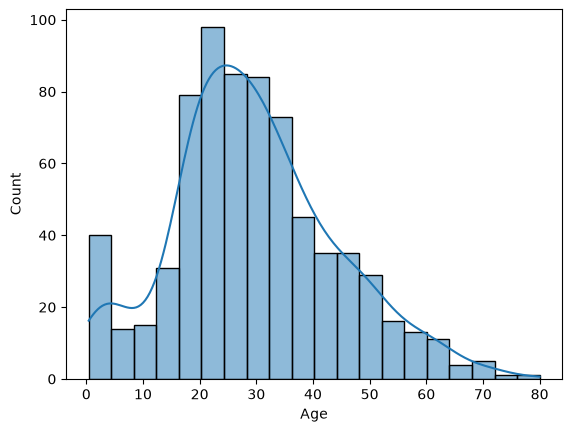

In [10]:
sns.histplot(x = df['Age'], data = df, kde=True)

Filling Missing values in 'Age' with its mean:

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


<Axes: xlabel='Age', ylabel='Count'>

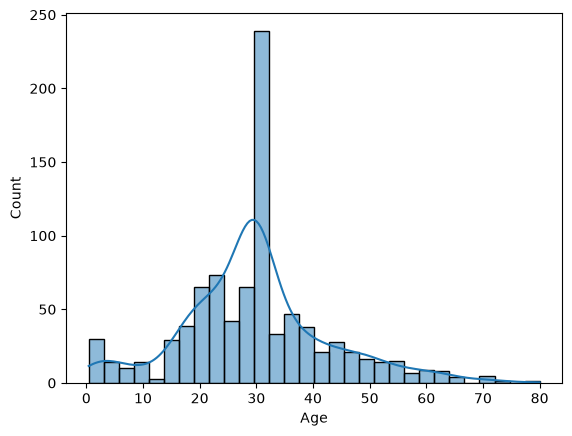

In [12]:
sns.histplot(x = df['Age'], data = df, kde=True)

In [13]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [14]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


## Experiment #01
- Dropped irrelevant columns: `Name`, `PassengerId`, `Ticket`
- Handled categorical variable `Sex` using binary mapping (0/1)
- Applied One-Hot Encoding on `Embarked`
- Trained a Logistic Regression model for classification

In [39]:
df1 = df.copy()

In [40]:
df1.drop(columns=['Name', 'PassengerId', 'Ticket'], inplace=True)

In [41]:
X = df1.drop("Survived", axis=1)
y = df1["Survived"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### One Hot Encoding on 'Embarked'

In [43]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[['Embarked']])
X_test_encoded = encoder.transform(X_test[['Embarked']])

In [44]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(['Embarked']),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(['Embarked']),
    index=X_test.index
)

In [45]:
X_train = X_train.drop(columns=['Embarked'])
X_test = X_test.drop(columns=['Embarked'])

X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

#### Converting 'Sex' to numerical feature

In [46]:
X_train["Sex"] = X_train["Sex"].map({
    "male": 0,
    "female": 1
})

X_test["Sex"] = X_test["Sex"].map({
    "male": 0,
    "female": 1
})

#### Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8100558659217877

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


Confusion Matrix:
 [[90 15]
 [19 55]]
